## Mount the drive


In [2]:
from google.colab import drive
import zipfile
import os


drive.mount('/content/drive')


Mounted at /content/drive


## Download Sentinel-2 sample

In [19]:
!pip install -q cdsetool
!pip install -q sentinelsat

In [20]:
import requests
import json
from sentinelsat import SentinelAPI
from google.colab import drive
import os
import zipfile
import shutil

In [21]:
SAVE_DIR = "/content/drive/MyDrive/.SAFE samples"
os.makedirs(SAVE_DIR, exist_ok=True)


In [47]:
import getpass

username = input('Copernicus username (email): ')
password = getpass.getpass('Copernicus password: ')

Copernicus username (email): l1d1am0ryc@gmail.com
Copernicus password: ··········


In [49]:
api = SentinelAPI(username, password, 'https://catalogue.dataspace.copernicus.eu/resto/api')

In [25]:
PRODUCT_NAME = "S2B_MSIL2A_20251107T095119_N0511_R079_T33UYR_20251107T104754.SAFE"


In [26]:
# get access product
def get_access_token(username, password):
    auth_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    data = {
        "grant_type": "password",
        "username": username,
        "password": password,
        "client_id": "cdse-public"
    }
    response = requests.post(auth_url, data=data)
    response.raise_for_status()
    return response.json()["access_token"]

In [27]:
def search_product(product_title, access_token):
    search_url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
    params = {
        "$filter": f"contains(Name,'{product_title}')"
    }
    headers = {"Authorization": f"Bearer {access_token}"}

    response = requests.get(search_url, params=params, headers=headers)
    response.raise_for_status()
    return response.json()


In [28]:
def download_product(product_id, access_token, output_path):
    download_url = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({product_id})/$value"
    headers = {"Authorization": f"Bearer {access_token}"}

    print(f"Downloading product {product_id}...")
    response = requests.get(download_url, headers=headers, stream=True)
    response.raise_for_status()

    total_size = int(response.headers.get('content-length', 0))
    downloaded = 0

    with open(output_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)
                if total_size > 0:
                    progress = (downloaded / total_size) * 100
                    print(f"\rProgress: {progress:.1f}%", end='')
    print("\nDownload complete!")

In [29]:
access_token = get_access_token(username, password)

results = search_product(PRODUCT_NAME, access_token)

if results['value']:
    product = results['value'][0]
    product_id = product['Id']
    product_name = product['Name']

    print(f"Found: {product_name}")
    print(f"Size: {product.get('ContentLength', 'Unknown')} bytes")

    # download to Google Drive
    output_path = f"/content/drive/MyDrive/.SAFE samples/{product_name}.zip"
    download_product(product_id, access_token, output_path)
else:
    print("Product not found!")

Found: S2B_MSIL2A_20251107T095119_N0511_R079_T33UYR_20251107T104754.SAFE
Size: 1218849492 bytes
Progress: 100.0%
Download complete!


In [30]:
zip_path = f"/content/drive/MyDrive/.SAFE samples/{product_name}.zip"
extract_path = "/content/drive/MyDrive/.SAFE samples/"

print("Extracting...")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()
    total_files = len(file_list)

    print(f"Total files to extract: {total_files}")

    # Extract with progress indication
    for i, file in enumerate(file_list, 1):
        zip_ref.extract(file, extract_path)
        if i % 100 == 0:
            print(f"Progress: {i}/{total_files} files ({(i/total_files)*100:.1f}%)")

print("\nExtraction complete")

# Move zip to Google Drive trash
if os.path.exists(zip_path):
    os.remove(zip_path)
    print(f"Deleted {product_name}.zip")

# verify the extracted folder
safe_folder = f"/content/drive/MyDrive/{product_name}"

if os.path.exists(safe_folder):
    print(f"\nSAFE folder created at: {safe_folder}")

    total_size = sum(
        os.path.getsize(os.path.join(dirpath, filename))
        for dirpath, dirnames, filenames in os.walk(safe_folder)
        for filename in filenames
    )
    print(f"Extracted folder size: {total_size / (1024**3):.2f} GB")
else:
    print("Extraction failed")

Extracting...
Total files to extract: 95

Extraction complete
Deleted S2B_MSIL2A_20251107T095119_N0511_R079_T33UYR_20251107T104754.SAFE.zip
Extraction failed


## Load hyperspectral data cube

In [11]:
!pip install spectral rasterio pyproj matplotlib numpy -q


In [3]:
import numpy as np
import spectral.io.envi as envi
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [12]:
HDR_PATH = '/content/drive/MyDrive/mggp_naloty/Obrazy lotnicze/221000_Odra_HS_Blok_A_013_VS_join_atm.hdr'

img  = envi.open(HDR_PATH)
meta = img.metadata

# Wavelength array
wavelengths = np.array([float(w) for w in meta['wavelength']])
ignore_val  = float(meta.get('data ignore value', -9999))

DECIMATE = 5   # spatial decimation for preview reads (adjust to taste)

print(f'Cube: {img.nrows} × {img.ncols} × {img.nbands} bands')
print(f'Wavelength range: {wavelengths[0]:.1f} – {wavelengths[-1]:.1f} nm')
print(f'Ignore value: {ignore_val}')

Cube: 1800 × 4324 × 456 bands
Wavelength range: 414.1 – 2498.9 nm
Ignore value: 15000.0


In [13]:
def nearest_band(target_nm: float) -> int:
    """Return 0-based band index closest to target wavelength."""
    return int(np.argmin(np.abs(wavelengths - target_nm)))

def read_band_dec(band_idx: int, decimate: int = DECIMATE) -> np.ma.MaskedArray:
    """Read one band, decimate, mask no-data and negatives."""
    arr = img.read_bands([band_idx]).astype(np.float32)[::decimate, ::decimate, 0]
    arr[arr >= ignore_val] = np.nan
    arr[arr < 0] = np.nan
    return arr

def read_bands_dec(*target_nms, decimate: int = DECIMATE):
    """Read multiple bands by wavelength (nm), return list of 2-D arrays."""
    return [read_band_dec(nearest_band(nm), decimate) for nm in target_nms]

print('Band utilities ready.')
print('Example — band nearest 560 nm:', nearest_band(560), f'({wavelengths[nearest_band(560)]:.1f} nm)')

Band utilities ready.
Example — band nearest 560 nm: 46 (561.2 nm)


## False-colour composites from the hyperspectral cube

In [14]:
def stretch(arr: np.ndarray, p_lo=2, p_hi=98) -> np.ndarray:
    """Per-channel percentile stretch to [0, 1]."""
    lo, hi = np.nanpercentile(arr, [p_lo, p_hi])
    return np.clip((arr - lo) / max(hi - lo, 1e-6), 0, 1)

def make_rgb(r_nm, g_nm, b_nm, label=''):
    r, g, b = read_bands_dec(r_nm, g_nm, b_nm)
    rgb = np.stack([stretch(r), stretch(g), stretch(b)], axis=-1)
    rgb = np.nan_to_num(rgb, nan=0.0)
    return rgb, label

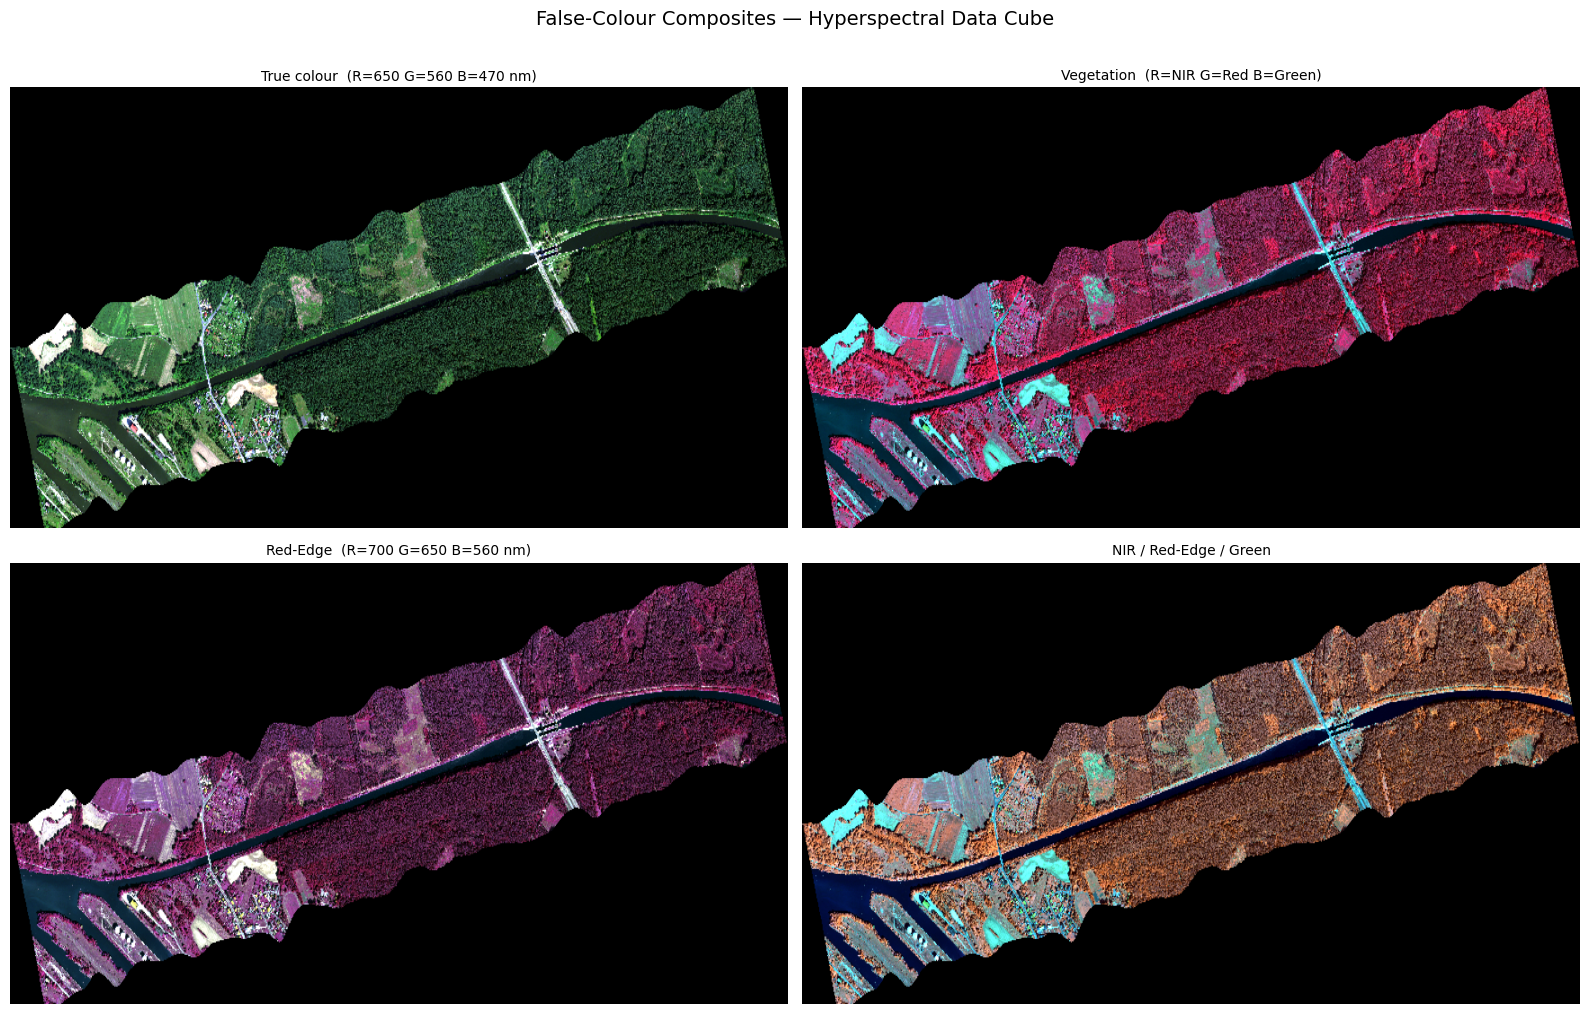

Saved: false_colour_composites.png


In [50]:
composites = [
    make_rgb(650, 560, 470,  'True colour  (R=650 G=560 B=470 nm)'),
    make_rgb(780, 650, 560,  'Vegetation  (R=NIR G=Red B=Green)'),
    make_rgb(700, 650, 560,  'Red-Edge  (R=700 G=650 B=560 nm)'),
    make_rgb(780, 700, 560,  'NIR / Red-Edge / Green'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('False-Colour Composites — Hyperspectral Data Cube', fontsize=14, y=1.01)

for ax, (rgb, label) in zip(axes.flat, composites):
    ax.imshow(rgb, interpolation='bilinear', aspect='auto')
    ax.set_title(label, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/false_colour_composites.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: false_colour_composites.png')

## Water quality indices

All indices use atmospherically corrected reflectance (the `atm` cube).

| Index | Formula | Target |
|---|---|---|
| **Chl-a** | (R700 − R670) / (R700 + R670) | Chlorophyll-a concentration |
| **DOC** | R490 / R560 | Dissolved Organic Carbon (CDOM proxy) |
| **Turbidity** | R850 / R560 | Suspended sediment / turbidity |

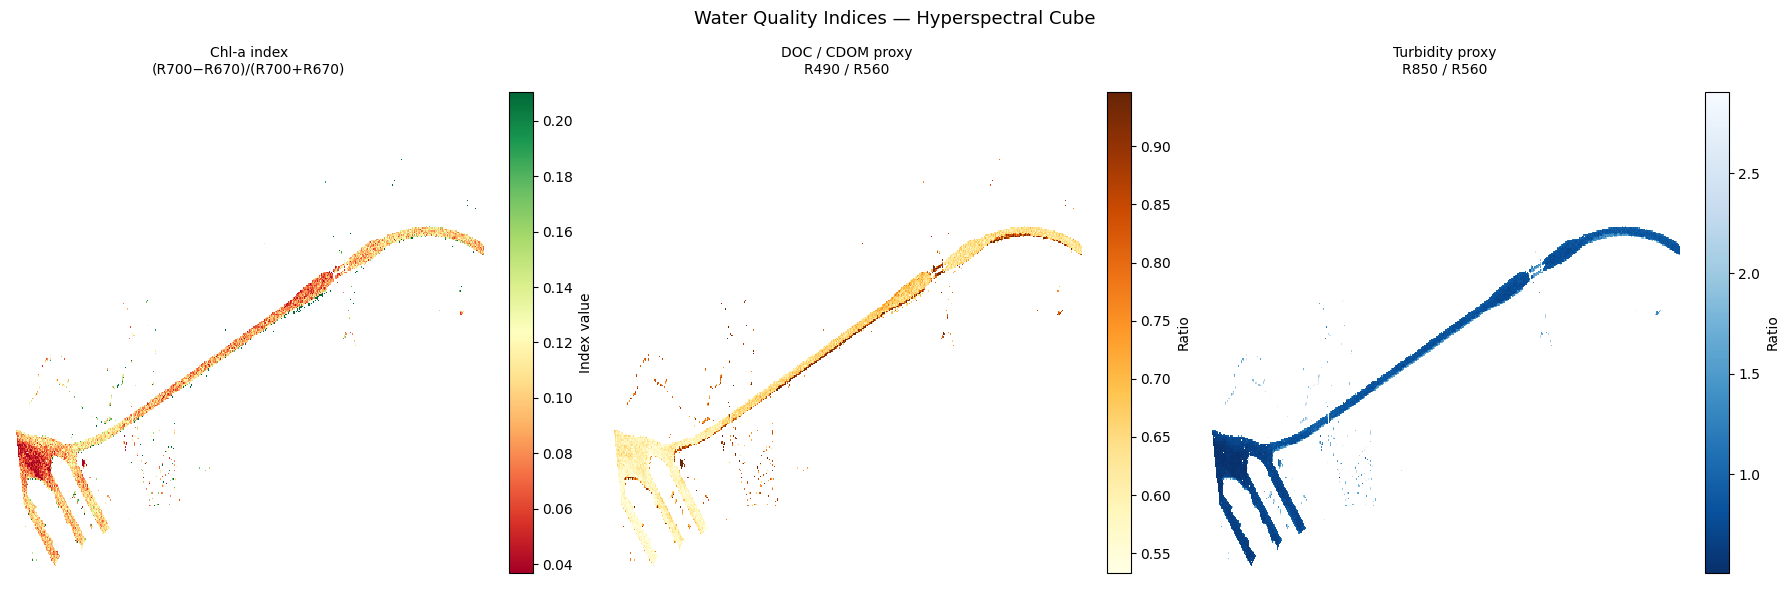

Chl-a       : mean=0.0967  std=0.0369  min=-0.0343  max=0.3799  n=11,841
DOC         : mean=0.6496  std=0.0994  min=0.4294  max=1.3682  n=11,841
Turbidity   : mean=0.9424  std=0.5505  min=0.3897  max=6.5467  n=11,841


In [51]:
R490, R560, R670, R700, R740, R850 = read_bands_dec(490, 560, 670, 700, 740, 850)

def safe_div(a, b):
    """Division with NaN where denominator is zero or both are NaN."""
    with np.errstate(invalid='ignore', divide='ignore'):
        result = np.where(np.abs(b) > 1e-9, a / b, np.nan)
    return result.astype(np.float32)

# Chl-a: normalised difference Red-Edge index
# Positive → high chlorophyll; near zero / negative → clear or turbid water
chla_hs = safe_div(R700 - R670, R700 + R670)

# DOC (CDOM proxy): higher ratio → more dissolved organic matter (yellower water)
doc_hs  = safe_div(R490, R560)

# Turbidity: NIR / Green — higher → more suspended sediment
turb_hs = safe_div(R850, R560)

water_mask = R850 < 0.05   # NIR < 5 % reflectance → likely water

def apply_water_mask(index):
    masked = index.copy()
    masked[~water_mask] = np.nan
    return masked

chla_hs_w = apply_water_mask(chla_hs)
doc_hs_w  = apply_water_mask(doc_hs)
turb_hs_w = apply_water_mask(turb_hs)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Water Quality Indices — Hyperspectral Cube', fontsize=13)

plots = [
    (chla_hs_w, 'RdYlGn',  'Chl-a index\n(R700−R670)/(R700+R670)',  'Index value'),
    (doc_hs_w,  'YlOrBr',  'DOC / CDOM proxy\nR490 / R560',          'Ratio'),
    (turb_hs_w, 'Blues_r', 'Turbidity proxy\nR850 / R560',           'Ratio'),
]

for ax, (data, cmap, title, cbar_label) in zip(axes, plots):
    vmin, vmax = np.nanpercentile(data[np.isfinite(data)], [2, 98]) if np.any(np.isfinite(data)) else (0, 1)
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest', aspect='auto')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/water_quality_hyperspectral.png', dpi=150, bbox_inches='tight')
plt.show()

for name, arr in [('Chl-a', chla_hs_w), ('DOC', doc_hs_w), ('Turbidity', turb_hs_w)]:
    valid = arr[np.isfinite(arr)]
    if valid.size > 0:
        print(f'{name:12s}: mean={valid.mean():.4f}  std={valid.std():.4f}  '
              f'min={valid.min():.4f}  max={valid.max():.4f}  n={valid.size:,}')

## Load Sentinel-2 L2A bands

In [52]:
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import from_bounds
from pyproj import Transformer
import glob, os

SAFE_DIR = '/content/drive/MyDrive/.SAFE samples/S2B_MSIL2A_20251107T095119_N0511_R079_T33UYR_20251107T104754.SAFE'

# buffer = 500 around the hyperspectral block corners
AOI_CS2000 = {
    'x_min': 6510302.0 - 500,
    'x_max': 6514625.0 + 500,
    'y_min': 5579761.0 - 500,
    'y_max': 5581560.0 + 500,
}

def find_s2_band(safe_dir, band_name, resolution='10m'):
    patterns = [
        f'{safe_dir}/**/*_{band_name}_{resolution}.jp2',
        f'{safe_dir}/**/*_{band_name}_20m.jp2',
        f'{safe_dir}/**/*_{band_name}_60m.jp2',
        f'{safe_dir}/**/*_{band_name}.jp2',
    ]
    for pat in patterns:
        hits = glob.glob(pat, recursive=True)
        if hits:
            return hits[0]
    raise FileNotFoundError(f'Band {band_name} not found in {safe_dir}')

def read_s2_band_cropped(path: str, aoi_bounds_src_crs: tuple,
                          target_shape: tuple | None = None) -> np.ndarray:
    """
    Read only the AOI window from a S2 JP2 band.
    aoi_bounds_src_crs: (x_min, y_min, x_max, y_max) in the S2 file's CRS.
    """
    with rasterio.open(path) as src:
        transformer = Transformer.from_crs(
            "EPSG:2177", src.crs.to_epsg() or src.crs,
            always_xy=True
        )
        x_min, y_min = transformer.transform(
            aoi_bounds_src_crs[0], aoi_bounds_src_crs[1]
        )
        x_max, y_max = transformer.transform(
            aoi_bounds_src_crs[2], aoi_bounds_src_crs[3]
        )

        window = from_bounds(x_min, y_min, x_max, y_max, src.transform)

        if target_shape:
            data = src.read(
                1, window=window,
                out_shape=(target_shape[0], target_shape[1]),
                resampling=Resampling.bilinear
            ).astype(np.float32)
        else:
            data = src.read(1, window=window).astype(np.float32)

    data[data <= 0] = np.nan
    return data / 10000.0

# AOI as (x_min, y_min, x_max, y_max) in CS2000
aoi = (AOI_CS2000['x_min'], AOI_CS2000['y_min'],
       AOI_CS2000['x_max'], AOI_CS2000['y_max'])

band_files = {}
for band, res in [('B02','10m'), ('B03','10m'), ('B04','10m'),
                  ('B05','20m'), ('B08','10m'), ('B8A','20m')]:
    try:
        band_files[band] = find_s2_band(SAFE_DIR, band, res)
        print(f'{band}: {os.path.basename(band_files[band])}')
    except FileNotFoundError as e:
        print(f'WARNING: {e}')

b03_raw = read_s2_band_cropped(band_files['B03'], aoi)
REF_SHAPE = b03_raw.shape
print(f'\nCropped shape: {REF_SHAPE}  '
      f'(was 10980×10980, now ~{REF_SHAPE[0]*REF_SHAPE[1]//1000}K pixels)')

S2 = {}
for band in band_files:
    S2[band] = read_s2_band_cropped(band_files[band], aoi, target_shape=REF_SHAPE)
    print(f'{band} loaded — shape {S2[band].shape} — '
          f'mean: {np.nanmean(S2[band]):.4f}')

B02: T33UYR_20251107T095119_B02_10m.jp2
B03: T33UYR_20251107T095119_B03_10m.jp2
B04: T33UYR_20251107T095119_B04_10m.jp2
B05: T33UYR_20251107T095119_B05_20m.jp2
B08: T33UYR_20251107T095119_B08_10m.jp2
B8A: T33UYR_20251107T095119_B8A_20m.jp2

Cropped shape: (301, 521)  (was 10980×10980, now ~156K pixels)
B02 loaded — shape (301, 521) — mean: 0.1292
B03 loaded — shape (301, 521) — mean: 0.1409
B04 loaded — shape (301, 521) — mean: 0.1466
B05 loaded — shape (301, 521) — mean: 0.1788
B08 loaded — shape (301, 521) — mean: 0.2759
B8A loaded — shape (301, 521) — mean: 0.2832


## False-colour composites — Sentinel-2

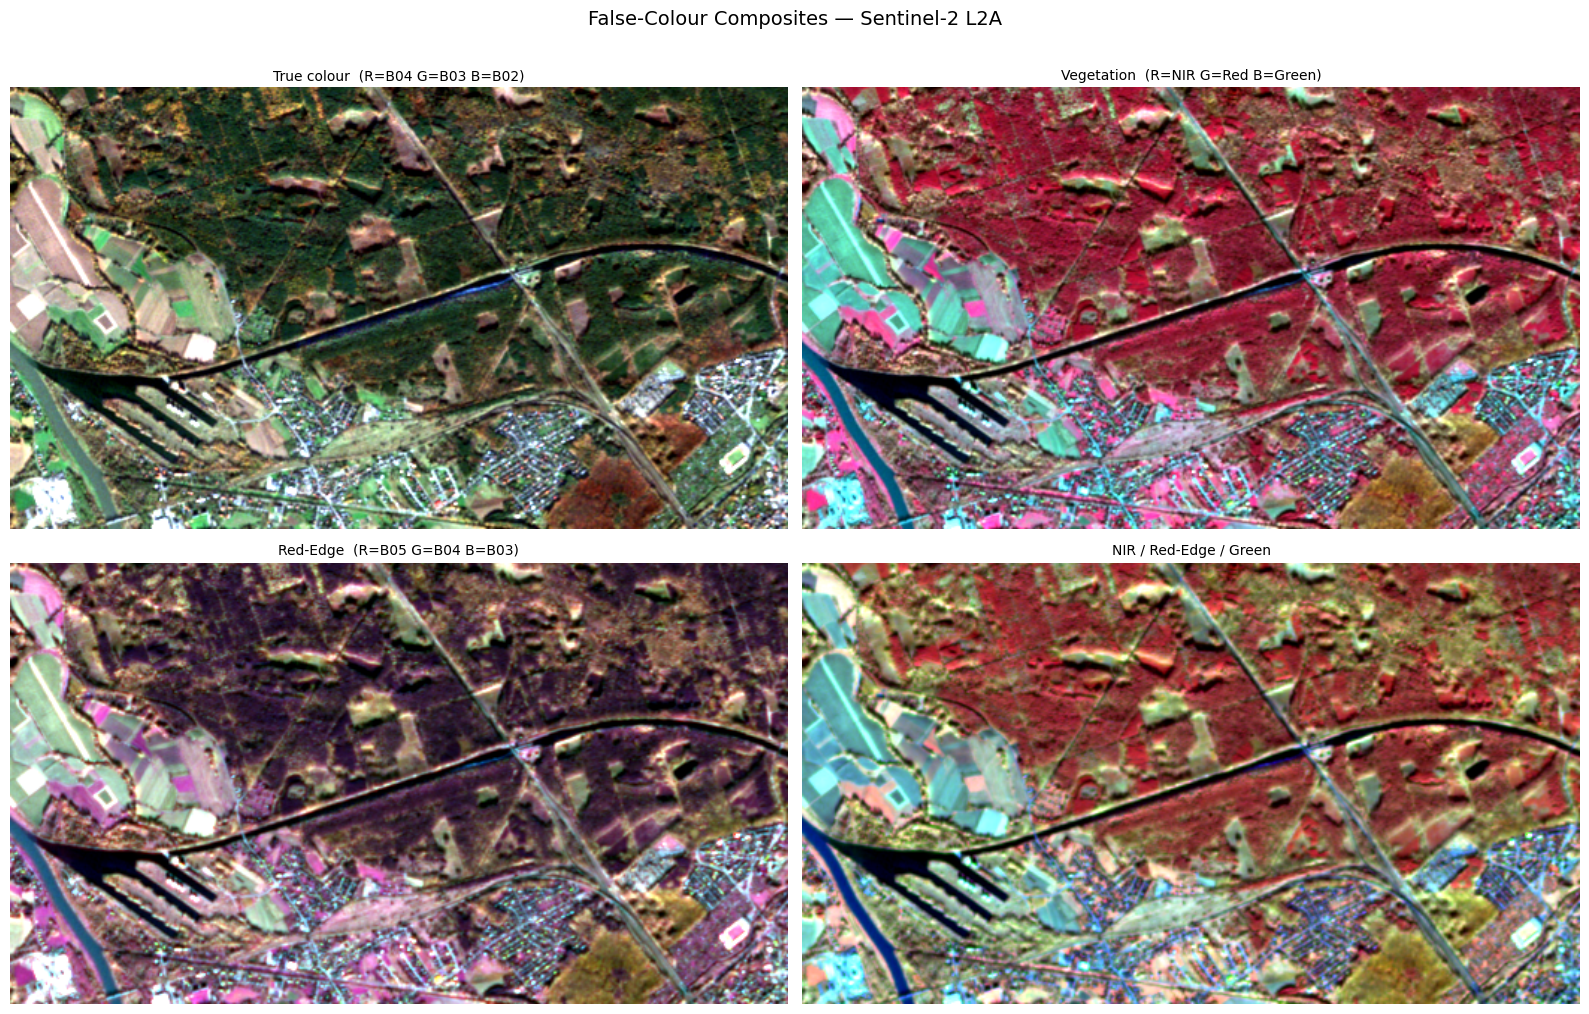

In [53]:
def make_s2_rgb(r_band, g_band, b_band, label=''):
    rgb = np.stack([
        stretch(S2[r_band]),
        stretch(S2[g_band]),
        stretch(S2[b_band])
    ], axis=-1)
    return np.nan_to_num(rgb, nan=0.0), label

s2_composites = [
    make_s2_rgb('B04', 'B03', 'B02', 'True colour  (R=B04 G=B03 B=B02)'),
    make_s2_rgb('B08', 'B04', 'B03', 'Vegetation  (R=NIR G=Red B=Green)'),
    make_s2_rgb('B05', 'B04', 'B03', 'Red-Edge  (R=B05 G=B04 B=B03)'),
    make_s2_rgb('B08', 'B05', 'B03', 'NIR / Red-Edge / Green'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('False-Colour Composites — Sentinel-2 L2A', fontsize=14, y=1.01)

for ax, (rgb, label) in zip(axes.flat, s2_composites):
    ax.imshow(rgb, interpolation='bilinear', aspect='auto')
    ax.set_title(label, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/false_colour_S2.png', dpi=150, bbox_inches='tight')
plt.show()

## Water quality indices - Sentinel-2

Same index formulas, mapped to the nearest Sentinel-2 bands:

| Index | Hyperspectral | Sentinel-2 |
|---|---|---|
| Chl-a | (R700−R670)/(R700+R670) | (B05−B04)/(B05+B04) |
| DOC | R490/R560 | B02/B03 |
| Turbidity | R850/R560 | B8A/B03 |

In [44]:
# Diagnose the water mask
b08 = S2['B08']
print(f"B08 range: {np.nanmin(b08):.4f} – {np.nanmax(b08):.4f}")
print(f"B08 mean:  {np.nanmean(b08):.4f}")
print(f"Pixels with B08 < 0.05: {np.sum(b08 < 0.05):,}")
print(f"Pixels with B08 < 0.10: {np.sum(b08 < 0.10):,}")
print(f"Pixels with B08 < 0.15: {np.sum(b08 < 0.15):,}")
print(f"Total valid pixels:      {np.sum(~np.isnan(b08)):,}")

B08 range: 0.0056 – 1.6572
B08 mean:  0.2855
Pixels with B08 < 0.05: 7
Pixels with B08 < 0.10: 11
Pixels with B08 < 0.15: 26,973
Total valid pixels:      820,997


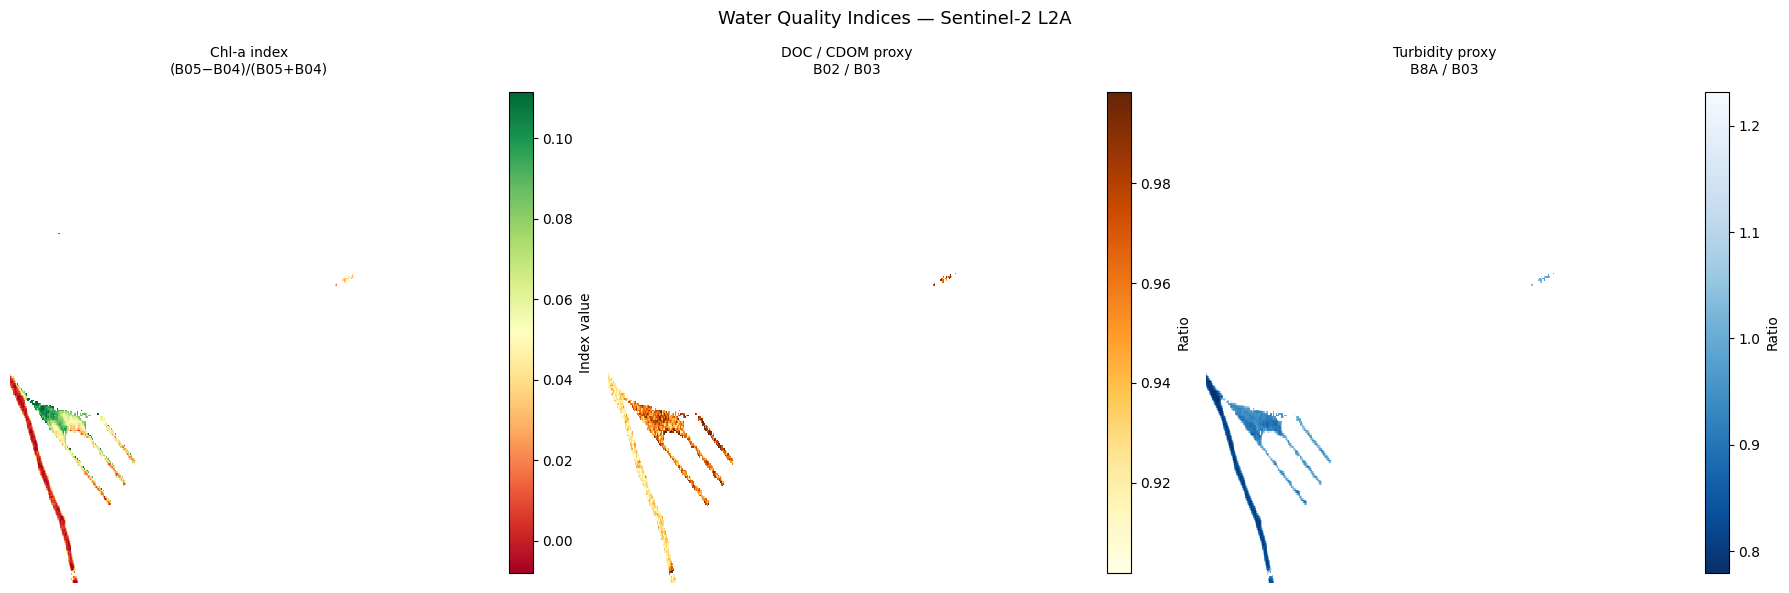

Chl-a       : mean=0.0421  std=0.0350  min=-0.0225  max=0.1438  n=2,153
DOC         : mean=0.9463  std=0.0253  min=0.8844  max=1.0413  n=2,153
Turbidity   : mean=0.9535  std=0.1164  min=0.7566  max=1.4291  n=2,153


In [54]:
water_mask_s2 = (S2['B08'] < 0.15) & (S2['B03'] > S2['B08'])

def apply_water_mask_s2(index):
    masked = index.copy()
    masked[~water_mask_s2] = np.nan
    return masked

chla_s2 = apply_water_mask_s2(safe_div(S2['B05'] - S2['B04'], S2['B05'] + S2['B04']))
doc_s2  = apply_water_mask_s2(safe_div(S2['B02'], S2['B03']))
turb_s2 = apply_water_mask_s2(safe_div(S2['B8A'], S2['B03']))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Water Quality Indices — Sentinel-2 L2A', fontsize=13)

plots_s2 = [
    (chla_s2, 'RdYlGn',  'Chl-a index\n(B05−B04)/(B05+B04)',  'Index value'),
    (doc_s2,  'YlOrBr',  'DOC / CDOM proxy\nB02 / B03',        'Ratio'),
    (turb_s2, 'Blues_r', 'Turbidity proxy\nB8A / B03',         'Ratio'),
]

for ax, (data, cmap, title, cbar_label) in zip(axes, plots_s2):
    valid_vals = data[np.isfinite(data)]
    vmin, vmax = np.nanpercentile(valid_vals, [2, 98]) if valid_vals.size > 0 else (0, 1)
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest', aspect='auto')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/water_quality_S2.png', dpi=150, bbox_inches='tight')
plt.show()

for name, arr in [('Chl-a', chla_s2), ('DOC', doc_s2), ('Turbidity', turb_s2)]:
    valid = arr[np.isfinite(arr)]
    if valid.size > 0:
        print(f'{name:12s}: mean={valid.mean():.4f}  std={valid.std():.4f}  '
              f'min={valid.min():.4f}  max={valid.max():.4f}  n={valid.size:,}')

## Side-by-side comparison -> Hyperspectral vs Sentinel-2

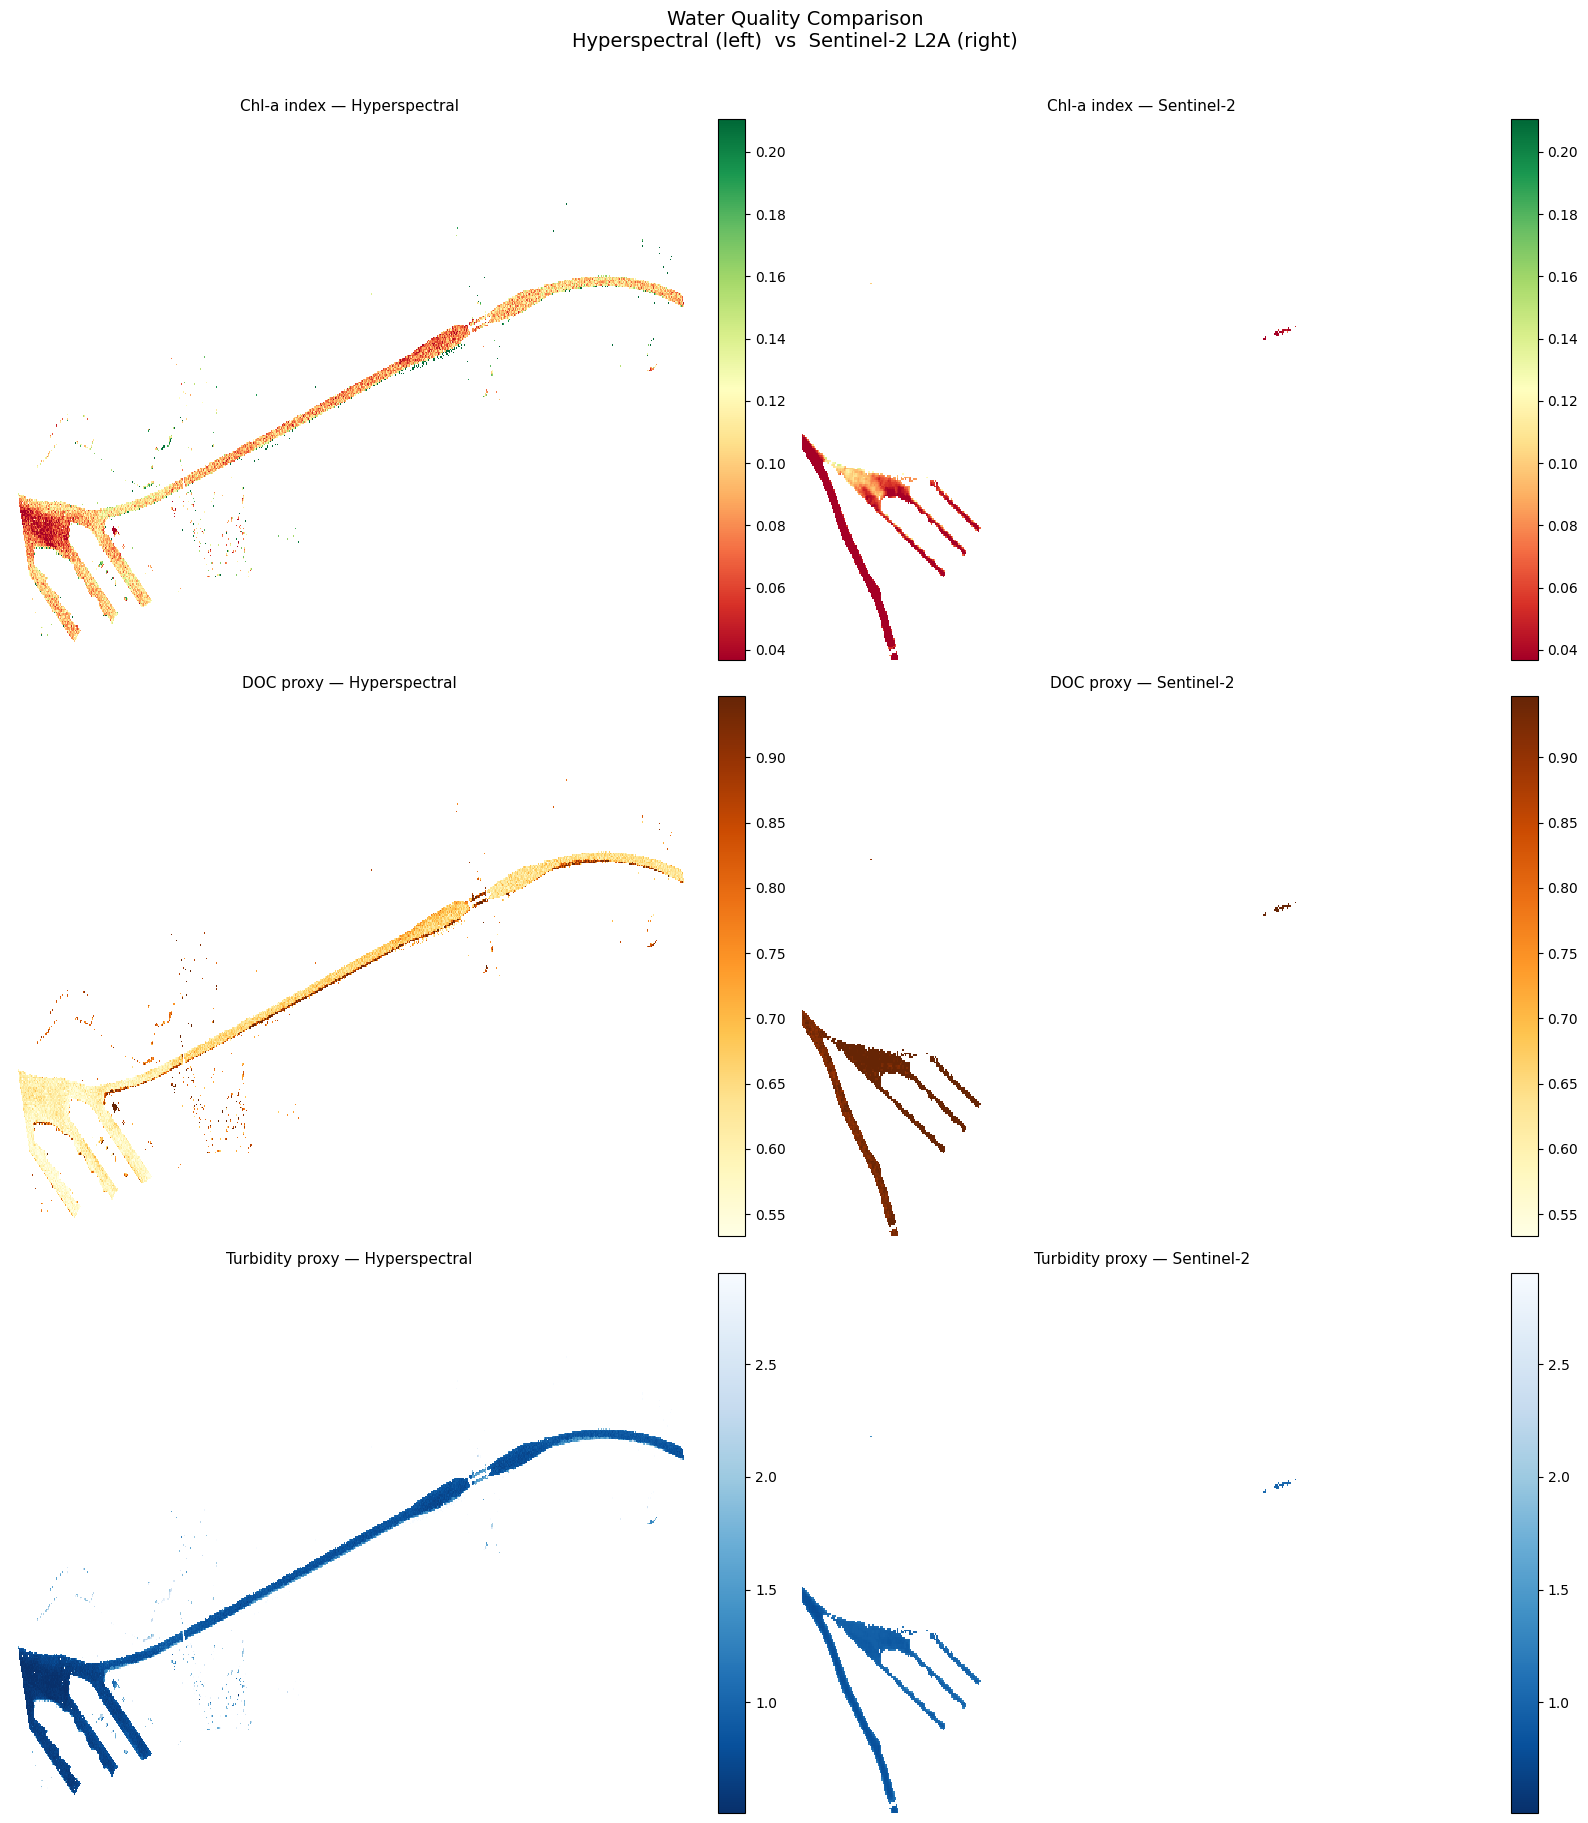

Saved: comparison_HS_vs_S2.png


In [55]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle(
    'Water Quality Comparison\nHyperspectral (left)  vs  Sentinel-2 L2A (right)',
    fontsize=14, y=1.01
)

pairs = [
    (chla_hs_w, chla_s2, 'RdYlGn',  'Chl-a index'),
    (doc_hs_w,  doc_s2,  'YlOrBr',  'DOC proxy'),
    (turb_hs_w, turb_s2, 'Blues_r', 'Turbidity proxy'),
]

for row, (hs_data, s2_data, cmap, title) in enumerate(pairs):
    valid_hs = hs_data[np.isfinite(hs_data)]
    vmin = np.nanpercentile(valid_hs, 2)  if valid_hs.size > 0 else 0
    vmax = np.nanpercentile(valid_hs, 98) if valid_hs.size > 0 else 1

    for col, (data, sensor) in enumerate([(hs_data, 'Hyperspectral'), (s2_data, 'Sentinel-2')]):
        ax = axes[row, col]
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax,
                       interpolation='nearest', aspect='auto')
        ax.set_title(f'{title} — {sensor}', fontsize=11)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/comparison_HS_vs_S2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_HS_vs_S2.png')

## Numerical summary comparison

In [35]:
import pandas as pd

rows = []
for index_name, hs_arr, s2_arr in [
    ('Chl-a',     chla_hs_w, chla_s2),
    ('DOC',       doc_hs_w,  doc_s2),
    ('Turbidity', turb_hs_w, turb_s2),
]:
    for sensor, arr in [('Hyperspectral', hs_arr), ('Sentinel-2', s2_arr)]:
        valid = arr[np.isfinite(arr)]
        if valid.size > 0:
            rows.append({
                'Index':   index_name,
                'Sensor':  sensor,
                'Mean':    round(float(valid.mean()), 5),
                'Std':     round(float(valid.std()),  5),
                'Min':     round(float(valid.min()),  5),
                'Max':     round(float(valid.max()),  5),
                'N pixels': int(valid.size),
            })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

csv_path = '/content/drive/MyDrive/water_quality_comparison.csv'
df.to_csv(csv_path, index=False)
print(f'\nSummary saved: {csv_path}')

    Index        Sensor    Mean     Std      Min     Max  N pixels
    Chl-a Hyperspectral 0.09675 0.03692 -0.03431 0.37991     11841
      DOC Hyperspectral 0.64961 0.09936  0.42938 1.36819     11841
Turbidity Hyperspectral 0.94245 0.55046  0.38968 6.54667     11841

Summary saved: /content/drive/MyDrive/water_quality_comparison.csv


## Extract samples


In [ ]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/mggp_naloty.zip'  # adjust path if needed
extract_to = '/content/drive/MyDrive/mggp_naloty/'    # output folder on Drive

os.makedirs(extract_to, exist_ok=True)

Mounted at /content/drive


In [ ]:
import json

progress_file = '/content/drive/MyDrive/extraction_progress.json'

# Load progress if resuming
if os.path.exists(progress_file):
    with open(progress_file) as f:
        done = set(json.load(f))
else:
    done = set()

with zipfile.ZipFile(zip_path, 'r') as z:
    for member in z.namelist():
        if member in done:
            print(f"Skipping (already done): {member}")
            continue
        print(f"Extracting: {member} ...")
        z.extract(member, extract_to)
        done.add(member)
        with open(progress_file, 'w') as f:
            json.dump(list(done), f)
        print(f"  Saved progress.")

Extracting: Obrazy lotnicze/ ...
  Saved progress.
Extracting: Obrazy lotnicze/221000_Odra_HS_Blok_A_006_VS_join_atm.bsq ...
  Saved progress.
Extracting: Obrazy lotnicze/221000_Odra_HS_Blok_A_007_VS_join_atm.bsq ...
  Saved progress.
Extracting: Obrazy lotnicze/221000_Odra_HS_Blok_A_008_VS_join_atm.bsq ...
  Saved progress.
Extracting: Obrazy lotnicze/221000_Odra_HS_Blok_A_008_VS_join_atm.bsq.aux.xml ...
  Saved progress.
Extracting: Obrazy lotnicze/221000_Odra_HS_Blok_A_008_VS_join_atm.hdr ...
  Saved progress.
Extracting: Obrazy lotnicze/221000_Odra_HS_Blok_A_013_VS_join_atm.bsq ...
  Saved progress.
Extracting: Obrazy lotnicze/221000_Odra_HS_Blok_A_013_VS_join_atm.bsq.aux.xml ...
  Saved progress.
Extracting: Obrazy lotnicze/221000_Odra_HS_Blok_A_013_VS_join_atm.hdr ...
  Saved progress.
Extracting: Obrazy lotnicze/221000_Odra_HS_Blok_A_015_VS_join_atm.bsq ...
  Saved progress.
Extracting: Obrazy lotnicze/221000_Odra_HS_Blok_A_015_VS_join_atm.hdr ...
  Saved progress.
